# Naive Bayes – Car Crash Severity Prediction
**Target Variable:** `Severity` (0 = Minor/No Injury, 1 = Severe/Fatal)  
**Dataset:** Car Crash – 112,660 records, 97 features (fully preprocessed)  
**Goal:** Predict whether a crash will result in a severe outcome using Bernoulli Naive Bayes.

**Why Bernoulli Naive Bayes?**  
Every feature in this dataset is already a binary 0/1 indicator (Clear Weather, Highway, Crash Type, Violation Category, County, Day of Week, Month).  
BernoulliNB is specifically designed for this structure — it models the probability that each binary feature is present or absent for each class.  
Unlike KNN or Logistic Regression, it requires **no feature scaling**, making it fast, interpretable, and ideal for high-dimensional binary data.

---
## Step 1 – Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Step 2 – Load the Preprocessed Data

In [2]:
df = pd.read_csv("Car_Crash_Fully_Preprocessed.csv")

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"Missing : {df.isnull().sum().sum()}")
df.head()

Rows    : 112,660
Columns : 98
Missing : 0


,Severity,ClearWeather,Highway,Daylight,CrashType_A,CrashType_B,CrashType_C,CrashType_D,CrashType_E,CrashType_F,...,Month_11,Month_12,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9
0,1,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


---
## Step 3 – Separate Features (X) and Target (y)
- **X** = all columns except `Severity` (the predictors)
- **y** = `Severity` (what we are predicting)

In [3]:
X = df.drop(columns=["Severity"])
y = df["Severity"]

print(f"Feature matrix X : {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"Target vector  y : {y.shape[0]:,} values")
print(f"\nAll features are binary (0/1): {(X.isin([0, 1]).all()).all()}")
print(f"\nFeature names:\n{list(X.columns)}")

Feature matrix X : 112,660 rows x 97 columns
Target vector  y : 112,660 values

All features are binary (0/1): True

Feature names:
['ClearWeather', 'Highway', 'Daylight', 'CrashType_A', 'CrashType_B', 'CrashType_C', 'CrashType_D', 'CrashType_E', 'CrashType_F', 'CrashType_G', 'ViolCat_1', 'ViolCat_10', 'ViolCat_11', 'ViolCat_12', 'ViolCat_24', 'ViolCat_3', 'ViolCat_4', 'ViolCat_6', 'ViolCat_7', 'ViolCat_8', 'ViolCat_9', 'County_0', 'County_1', 'County_10', 'County_11', 'County_12', 'County_13', 'County_14', 'County_15', 'County_16', 'County_17', 'County_18', 'County_19', 'County_2', 'County_20', 'County_21', 'County_22', 'County_23', 'County_24', 'County_25', 'County_26', 'County_27', 'County_28', 'County_29', 'County_3', 'County_30', 'County_31', 'County_32', 'County_33', 'County_34', 'County_35', 'County_36', 'County_37', 'County_38', 'County_39', 'County_4', 'County_40', 'County_41', 'County_42', 'County_43', 'County_44', 'County_45', 'County_46', 'County_47', 'County_48', 'County_4

---
## Step 4 – Check Class Imbalance
Class imbalance occurs when one outcome is far more common than the other.  
If ignored, the model will be biased toward always predicting the majority class (Minor) and miss nearly all severe crashes.

**Solution for Naive Bayes:** Set `class_prior=[0.5, 0.5]` to give both classes equal prior probability during training.  
This is equivalent to `class_weight='balanced'` used in Logistic Regression — it forces the model to treat each class as equally likely before observing the features.

Class Distribution:
  Severity = 0 (Minor)  : 104,742  (93.0%)
  Severity = 1 (Severe) :   7,918  (7.0%)

>> Imbalance detected (~93% / ~7%).
   Solution: use class_prior=[0.5, 0.5] so the model gives
   equal prior weight to both classes before seeing any features.


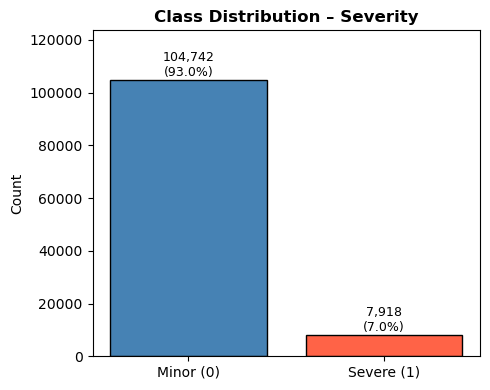

In [4]:
counts = y.value_counts()

print("Class Distribution:")
print(f"  Severity = 0 (Minor)  : {counts[0]:>7,}  ({counts[0]/len(y)*100:.1f}%)")
print(f"  Severity = 1 (Severe) : {counts[1]:>7,}  ({counts[1]/len(y)*100:.1f}%)")
print()
print(">> Imbalance detected (~93% / ~7%).")
print("   Solution: use class_prior=[0.5, 0.5] so the model gives")
print("   equal prior weight to both classes before seeing any features.")

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Minor (0)", "Severe (1)"], counts.values, color=["steelblue", "tomato"], edgecolor="black")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f"{val:,}\n({val/len(y)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Class Distribution – Severity", fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, counts[0] * 1.18)
plt.tight_layout()
plt.show()

---
## Step 5 – Train / Test Split
- **75% training** – the model learns the probability of each feature given each class
- **25% testing** – held out and never seen during training; used to evaluate real-world performance
- `stratify=y` ensures the 93/7 class ratio is preserved in both splits

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print()
print("Training class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())
print()
print("Note: No feature scaling is needed for Naive Bayes.")
print("BernoulliNB works directly with raw 0/1 values — it computes")
print("P(feature=1 | class) and P(feature=0 | class) directly from counts.")

Training set : 84,495 rows
Test set     : 28,165 rows

Training class distribution:
Severity
0    78556
1     5939
Name: count, dtype: int64

Test class distribution:
Severity
0    26186
1     1979
Name: count, dtype: int64

Note: No feature scaling is needed for Naive Bayes.
BernoulliNB works directly with raw 0/1 values — it computes
P(feature=1 | class) and P(feature=0 | class) directly from counts.


---
## Step 6 – Build and Train the Naive Bayes Model
**How Bernoulli Naive Bayes works:**  
For each crash, the model computes the probability of being Severe vs. Minor by multiplying together the probability of each feature given that class. The "Naive" assumption is that all features are conditionally independent — knowing one feature (e.g., Highway = 1) doesn't tell us anything about another (e.g., ClearWeather = 1) once we know the class.

Key parameters:
- `alpha=1.0` – Laplace smoothing; prevents zero probabilities for feature/class combinations not seen in training data
- `class_prior=[0.5, 0.5]` – equal prior weight for Minor and Severe, overriding the raw 93/7 imbalance

In [7]:
model = BernoulliNB(
    alpha=1.0,
    class_prior=[0.5, 0.5]
)

model.fit(X_train, y_train)

print("Model training complete.")
print(f"  Model type        : BernoulliNB")
print(f"  Alpha (smoothing) : {model.alpha}")
print(f"  Class prior       : {model.class_prior}")
print(f"  Classes           : {model.classes_}")
print(f"  Number of features: {model.n_features_in_}")
print()
print("Learned class log-priors (log scale):")
for cls, lp in zip(model.classes_, model.class_log_prior_):
    print(f"  Class {cls}: log-prior = {lp:.4f}")

Model training complete.
  Model type        : BernoulliNB
  Alpha (smoothing) : 1.0
  Class prior       : [0.5, 0.5]
  Classes           : [0 1]
  Number of features: 97

Learned class log-priors (log scale):
  Class 0: log-prior = -0.6931
  Class 1: log-prior = -0.6931


---
## Step 7 – Generate Predictions
- `y_pred` – hard class labels (0 or 1)
- `y_pred_prob` – probability that each crash is Severe (used for AUC-ROC)

In [8]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # P(Severity = 1)

print(f"Predictions generated for {len(y_pred):,} test records.")
print(f"\nSample predicted labels      : {y_pred[:10]}")
print(f"Sample predicted probabilities: {y_pred_prob[:10].round(3)}")

Predictions generated for 28,165 test records.

Sample predicted labels      : [1 0 0 1 1 0 0 0 0 0]
Sample predicted probabilities: [0.505 0.194 0.33  0.947 0.907 0.19  0.171 0.11  0.024 0.214]


---
## Step 8 – Evaluate Model Performance
### Metrics explained:
| Metric | What it means |
|---|---|
| **Precision** | Of crashes predicted Severe, how many actually were? |
| **Recall** | Of crashes that were actually Severe, how many did we catch? |
| **F1-Score** | Harmonic mean of precision and recall |
| **AUC-ROC** | Overall ranking quality — 0.5 = random, 1.0 = perfect |

In [9]:
auc_score = roc_auc_score(y_test, y_pred_prob)

print(f"AUC-ROC Score : {auc_score:.4f}")
print()

if auc_score >= 0.90:
    rating = "Excellent"
elif auc_score >= 0.80:
    rating = "Good"
elif auc_score >= 0.70:
    rating = "Acceptable"
else:
    rating = "Poor"
print(f"Rating: {rating}  (>0.70 = Acceptable | >0.80 = Good | >0.90 = Excellent)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Minor (0)", "Severe (1)"]))

AUC-ROC Score : 0.7453

Rating: Acceptable  (>0.70 = Acceptable | >0.80 = Good | >0.90 = Excellent)

Classification Report:
              precision    recall  f1-score   support

   Minor (0)       0.96      0.71      0.82     26186
  Severe (1)       0.14      0.64      0.23      1979

    accuracy                           0.71     28165
   macro avg       0.55      0.68      0.53     28165
weighted avg       0.91      0.71      0.78     28165



---
## Step 9 – Confusion Matrix
Shows exactly how many predictions were correct and incorrect for each class.

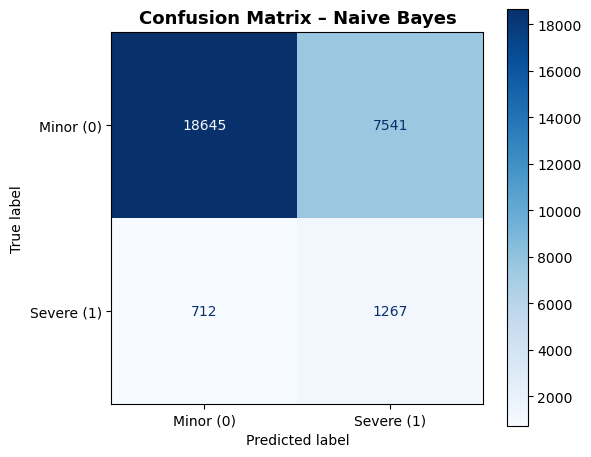

True Negatives  (correctly predicted Minor)  : 18,645
False Positives (predicted Severe, was Minor): 7,541
False Negatives (predicted Minor, was Severe): 712
True Positives  (correctly predicted Severe) : 1,267
Chart saved to: NB_Confusion_Matrix.png


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Minor (0)", "Severe (1)"])
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix – Naive Bayes", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("NB_Confusion_Matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted Minor)  : {tn:,}")
print(f"False Positives (predicted Severe, was Minor): {fp:,}")
print(f"False Negatives (predicted Minor, was Severe): {fn:,}")
print(f"True Positives  (correctly predicted Severe) : {tp:,}")
print("Chart saved to: NB_Confusion_Matrix.png")

---
## Step 10 – AUC-ROC Curve
The ROC curve plots the **True Positive Rate** vs **False Positive Rate** at every possible classification threshold.  
The **Area Under the Curve (AUC)** summarizes the model's ability to distinguish severe from minor crashes.  
A diagonal line (AUC = 0.50) represents a random classifier.

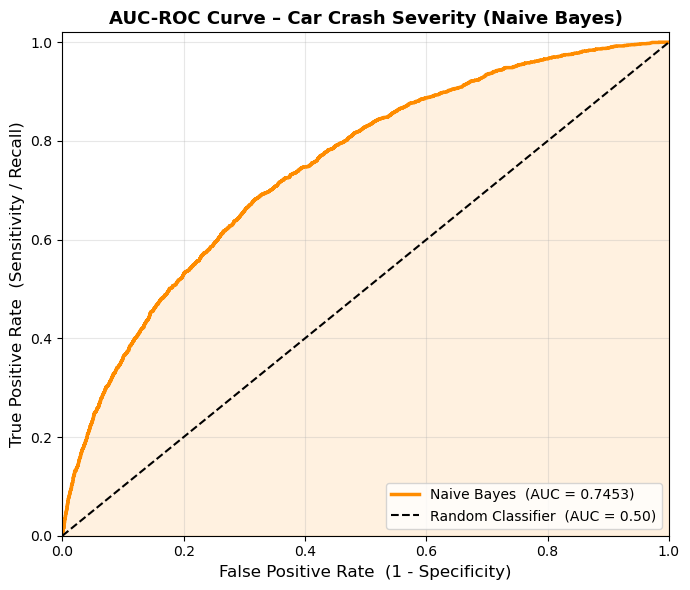

AUC-ROC Score: 0.7453
Chart saved to: NB_AUC_ROC_Curve.png


In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="darkorange", lw=2.5, label=f"Naive Bayes  (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Classifier  (AUC = 0.50)")
ax.fill_between(fpr, tpr, alpha=0.12, color="darkorange")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel("False Positive Rate  (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate  (Sensitivity / Recall)", fontsize=12)
ax.set_title("AUC-ROC Curve – Car Crash Severity (Naive Bayes)", fontweight="bold", fontsize=13)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("NB_AUC_ROC_Curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"AUC-ROC Score: {auc_score:.4f}")
print("Chart saved to: NB_AUC_ROC_Curve.png")

---
## Step 11 – Top Features by Severity Association
Naive Bayes learns `log P(feature=1 | class)` for every feature and class.  
By computing the **log probability ratio** — `log P(feature=1 | Severe) - log P(feature=1 | Minor)` — we get a score for how much more (or less) likely each feature is to appear in severe crashes versus minor ones.

- **Positive score** → feature is more common in Severe crashes (risk factor)
- **Negative score** → feature is more common in Minor crashes (protective factor)

Top 15 Features by Severity Association (Log Probability Ratio):
    Feature  Log_Ratio
  ViolCat_4  -2.148794
  County_24   2.042963
  County_51   1.776335
  County_21   1.763649
  County_44   1.665669
   County_1   1.626448
 ViolCat_11   1.581307
  County_31   1.463929
  County_16   1.395642
  County_13   1.367516
   County_4   1.208244
 ViolCat_24   1.195665
  County_10   1.195665
CrashType_G   1.163249
CrashType_C  -1.140620


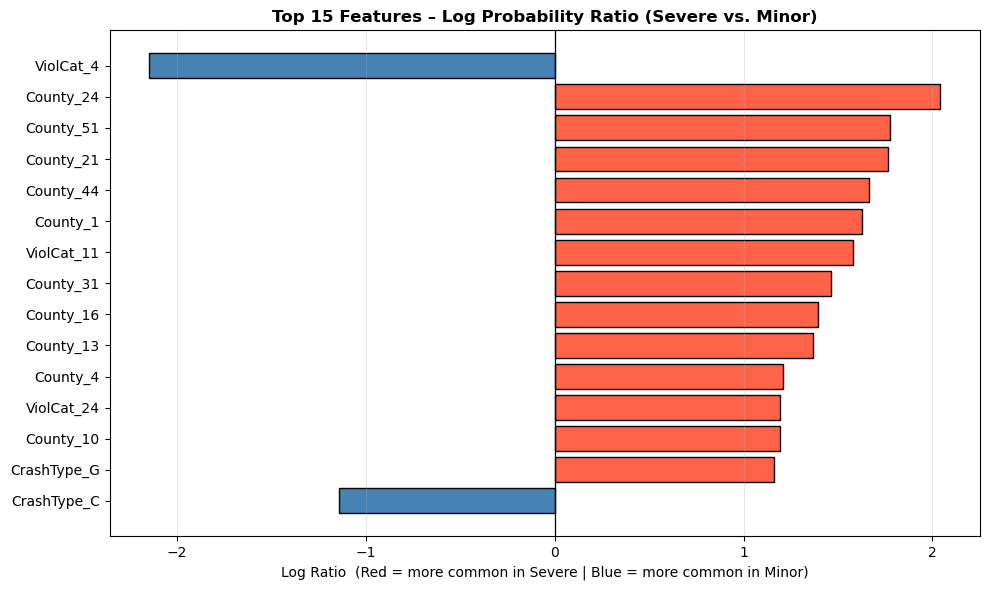

Chart saved to: NB_Feature_Importance.png


In [12]:
log_prob_severe = model.feature_log_prob_[1]   # log P(feature=1 | Severe)
log_prob_minor  = model.feature_log_prob_[0]   # log P(feature=1 | Minor)
log_ratio       = log_prob_severe - log_prob_minor

feature_df = pd.DataFrame({
    "Feature"  : X.columns,
    "Log_Ratio": log_ratio
})
feature_df["Abs_Log_Ratio"] = feature_df["Log_Ratio"].abs()
feature_df = feature_df.sort_values("Abs_Log_Ratio", ascending=False).head(15).reset_index(drop=True)

print("Top 15 Features by Severity Association (Log Probability Ratio):")
print(feature_df[["Feature", "Log_Ratio"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["tomato" if v > 0 else "steelblue" for v in feature_df["Log_Ratio"]]
ax.barh(feature_df["Feature"][::-1], feature_df["Log_Ratio"][::-1],
        color=colors[::-1], edgecolor="black")
ax.axvline(0, color="black", linewidth=0.9)
ax.set_title("Top 15 Features – Log Probability Ratio (Severe vs. Minor)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Log Ratio  (Red = more common in Severe | Blue = more common in Minor)", fontsize=10)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("NB_Feature_Importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to: NB_Feature_Importance.png")

---
## Step 12 – Predicted Probability Distribution
Shows how well the model separates the two classes.  
Ideally, blue (Minor) peaks near 0 and red (Severe) peaks near 1.

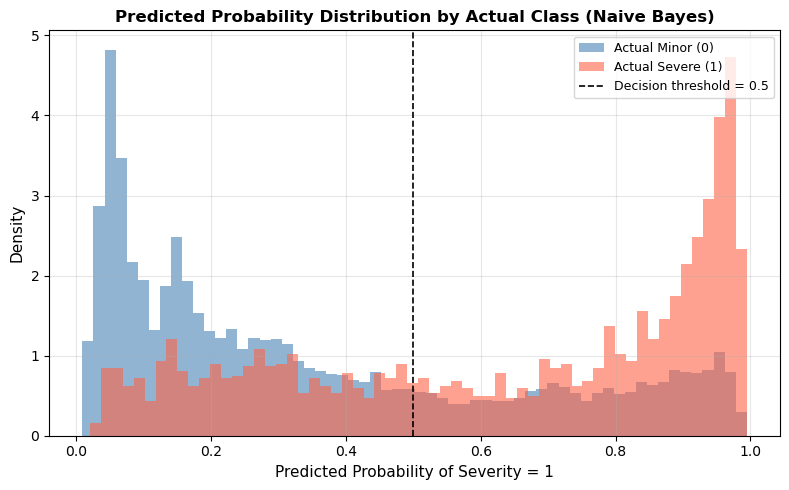

Chart saved to: NB_Probability_Distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_pred_prob[y_test == 0], bins=60, alpha=0.6, color="steelblue",
        label="Actual Minor (0)", density=True)
ax.hist(y_pred_prob[y_test == 1], bins=60, alpha=0.6, color="tomato",
        label="Actual Severe (1)", density=True)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="Decision threshold = 0.5")
ax.set_xlabel("Predicted Probability of Severity = 1", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Predicted Probability Distribution by Actual Class (Naive Bayes)",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("NB_Probability_Distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to: NB_Probability_Distribution.png")

---
## Step 13 – Model Comparison: Naive Bayes vs. Other Models
Place Naive Bayes results in context of the full project model suite.

Model Comparison – AUC-ROC:
              Model  AUC-ROC Train/Test Scaling Needed
Logistic Regression 0.752900      75/25            Yes
        Naive Bayes 0.745318      75/25             No
          KNN (k=5) 0.606500      70/30            Yes


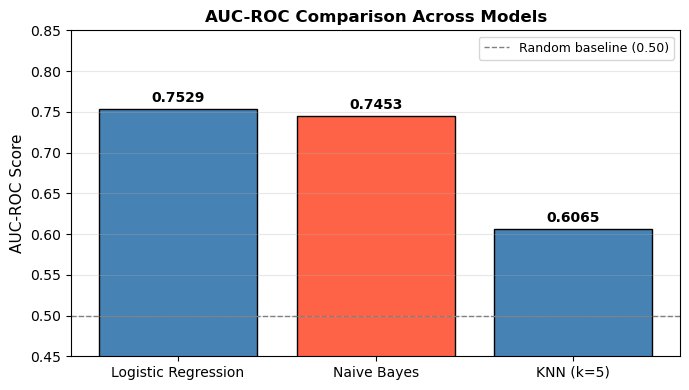

Chart saved to: NB_Model_Comparison.png


In [14]:
comparison = pd.DataFrame({
    "Model"         : ["KNN (k=5)", "Logistic Regression", "Naive Bayes"],
    "AUC-ROC"       : [0.6065, 0.7529, auc_score],
    "Train/Test"    : ["70/30", "75/25", "75/25"],
    "Scaling Needed": ["Yes", "Yes", "No"],
})
comparison = comparison.sort_values("AUC-ROC", ascending=False).reset_index(drop=True)

print("Model Comparison – AUC-ROC:")
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ["tomato" if m == "Naive Bayes" else "steelblue" for m in comparison["Model"]]
bars = ax.bar(comparison["Model"], comparison["AUC-ROC"], color=bar_colors, edgecolor="black")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random baseline (0.50)")
for bar, val in zip(bars, comparison["AUC-ROC"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0.45, 0.85)
ax.set_ylabel("AUC-ROC Score", fontsize=11)
ax.set_title("AUC-ROC Comparison Across Models", fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("NB_Model_Comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to: NB_Model_Comparison.png")

---
## Step 14 – Full Results Summary

In [15]:
print("=" * 55)
print("         NAIVE BAYES – FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"  Dataset           : Car Crash ({len(df):,} records)")
print(f"  Target            : Severity (0=Minor, 1=Severe)")
print(f"  Train / Test split: 75% / 25% (stratified)")
print(f"  Features used     : {X.shape[1]}")
print(f"  Feature scaling   : Not required (binary features)")
print(f"  Class prior       : Balanced [0.5, 0.5]")
print(f"  Laplace smoothing : alpha = 1.0")
print()
print(f"  AUC-ROC Score     : {auc_score:.4f}  [{rating}]")
print()
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"  True  Positives   : {tp:,}   (Severe crashes correctly identified)")
print(f"  False Negatives   : {fn:,}   (Severe crashes missed)")
print(f"  True  Negatives   : {tn:,}  (Minor crashes correctly identified)")
print(f"  False Positives   : {fp:,}   (Minor crashes incorrectly flagged as Severe)")
print()
print("  Saved files:")
print("    NB_Confusion_Matrix.png")
print("    NB_AUC_ROC_Curve.png")
print("    NB_Feature_Importance.png")
print("    NB_Probability_Distribution.png")
print("    NB_Model_Comparison.png")
print("=" * 55)

         NAIVE BAYES – FINAL RESULTS SUMMARY
  Dataset           : Car Crash (112,660 records)
  Target            : Severity (0=Minor, 1=Severe)
  Train / Test split: 75% / 25% (stratified)
  Features used     : 97
  Feature scaling   : Not required (binary features)
  Class prior       : Balanced [0.5, 0.5]
  Laplace smoothing : alpha = 1.0

  AUC-ROC Score     : 0.7453  [Acceptable]

  True  Positives   : 1,267   (Severe crashes correctly identified)
  False Negatives   : 712   (Severe crashes missed)
  True  Negatives   : 18,645  (Minor crashes correctly identified)
  False Positives   : 7,541   (Minor crashes incorrectly flagged as Severe)

  Saved files:
    NB_Confusion_Matrix.png
    NB_AUC_ROC_Curve.png
    NB_Feature_Importance.png
    NB_Probability_Distribution.png
    NB_Model_Comparison.png
